In [34]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
import torch.nn as nn
import torch.nn.functional as F
import math
import json
from tqdm import tqdm
import more_itertools as mit
import copy
import time
import random

random.seed(2)
torch.manual_seed(2)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
import numpy as np
from sklearn import preprocessing
import scipy.io as sio
from sklearn import linear_model
from scipy import interpolate
import csv


In [36]:
from utils.preprocessing import Data_preprocess , processing
from model.positional_encoding import PositionalEncoding
from model.encoder import EncoderLayer , TransformerEncoder
from model.decoder import DecoderLayer , TransformerDecoder
from model.multihead_attention import MultiHeadSelfAttention
from model.dense_layer import Dense_Layer
from utils.trainer import Trainer

In [37]:
# check if gpu is available and choose the best device
device = "cuda" if torch.cuda.is_available() else "cpu"

In [38]:
device

'cpu'

# All Preprocess Func

In [39]:
class cmapss_dataset(Dataset):
    def __init__(self, x_data, y_data):
        self.x_data = torch.from_numpy(x_data).to(device).to(torch.float64)  # Convert numpy array to PyTorch tensor
        self.y_data = torch.from_numpy(y_data[0]).to(device).to(torch.float64)
        
    def __getitem__(self, index):
        x = self.x_data[index]
        y = self.y_data[index]
        y = y.reshape((1))
        return x, y
    
    def __len__(self):
        return len(self.x_data)

In [40]:
seq_len = 60
data = processing ('./cmapssdata/train_FD001.txt', 
                   './cmapssdata/test_FD001.txt', 
                   './cmapssdata/RUL_FD001.txt',
                   seq_len , [2, 3, 4, 5, 9, 10, 14, 20, 22, 23], 125.0, 14)
trainX, trainY, testX, testY = data.get_data()

In [41]:
train_dataset = cmapss_dataset(trainX,trainY)
test_dataset = cmapss_dataset(testX,testY)

In [42]:
next(iter(train_dataset))[0].shape ,next(iter(train_dataset))[1].shape

(torch.Size([60, 14]), torch.Size([1]))

## To DataLoaders

In [43]:
def create_data_loaders(train_dataset,test_dataset , batch_size, shuffle=True):
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=shuffle)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader , test_loader

In [44]:
batch_size = 64
train_loader, test_loader = create_data_loaders(
        train_dataset, test_dataset , batch_size
    )

In [45]:
next(iter(train_loader))[0].shape

torch.Size([64, 60, 14])

# Model 

# Transformer

In [97]:
class DenoisingJointEmbedding(nn.Module):

    def __init__(
        self,
        n_features,
        window_size,
        enc_seq_len,
        out_dim,
        n_encoder_layers =3,
        n_decoder_layers = 1,
        n_heads=7,
        ff_hidden = 1024
    ):
        super(DenoisingJointEmbedding, self).__init__()
        
        #transformer design
        d_model = n_features
        self.transformer_encoder = TransformerEncoder(n_encoder_layers, n_heads, d_model , ff_hidden, window_size)
        self.dense_layer_regressor = Dense_Layer(d_model,enc_seq_len)
        
    def forward(self, x):
        # x shape (b, n, k): b - batch size, n - window size, k - number of features
        x = x.to(torch.float64)
        x = x[:,:enc_seq_len]
        h_cat = x
        encoder_out_vector = self.transformer_encoder(h_cat)
        predictions = self.dense_layer_regressor(encoder_out_vector)
        return predictions

In [98]:
#The number of useful sensors (which means the number of features) 
useful_sensors_number = 14
# FD001 best config : head = 7 , n_enc = 3 , n_dec = 2
dim_val = 14 #64
dim_attn = 14 #64
n_heads = 2

n_encoder_layers = 1

max_rul = 125
lr = 0.001 
enc_seq_len = trainX.shape[1]
output_sequence_length = 1  

In [99]:
n_features = trainX.shape[2]
window_size = enc_seq_len
out_dim = n_features
feat_gat_embed_dim = None
time_gat_embed_dim = None
use_gatv2 = True
alpha = 0.2
dropout = 0.1


In [100]:
model = DenoisingJointEmbedding(
        n_features,
        window_size,
        enc_seq_len,
        out_dim,
        n_encoder_layers = n_encoder_layers,
        n_decoder_layers = n_decoder_layers,
        n_heads=n_heads
    )

In [101]:
model

DenoisingJointEmbedding(
  (transformer_encoder): TransformerEncoder(
    (pos_encoding): PositionalEncoding()
    (encoder_layers): ModuleList(
      (0): EncoderLayer(
        (self_attn): MultiHeadSelfAttention(
          (linear_q): Linear(in_features=14, out_features=14, bias=True)
          (linear_k): Linear(in_features=14, out_features=14, bias=True)
          (linear_v): Linear(in_features=14, out_features=14, bias=True)
          (linear_out): Linear(in_features=14, out_features=14, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feedforward): Sequential(
          (0): Linear(in_features=14, out_features=1024, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=1024, out_features=14, bias=True)
          (4): Dropout(p=0.1, inplace=False)
        )
        (norm1): LayerNorm((14,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((14,), eps=1e-05, elementwise_affine=Tru

# Model To Gpu

In [102]:
model = model.to(device)
model = model.to(torch.float64)

## Training

#### define RUL Loss function

In [103]:
class RMSELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()
    def forward(self,yhat,y,mode="train",overestimation_penalty=True):
        # L2 regularization
        l2_lambda = 0.1
        l2_norm = sum(p.pow(2.0).sum()
                      for p in list(model.parameters())[-4:])
        L2_regularization = l2_lambda*l2_norm
        
        # Asymetric score
        asym_penalty_unit = torch.tensor([0.0])
        #asym_penalty_rate = 0.001
        diff = yhat - y
        #penalty_unit = torch.where(diff >= 0 , diff , 0.0  ).to(device, dtype=torch.float64)
        #asym_penalty_unit = torch.where(diff >= 0 , torch.exp(diff/13.0) - 1 , torch.exp(-(diff/10.0)) - 1 ).to(device, dtype=torch.float64)
        if mode == "train" :
            #asym_score_penalty = asym_penalty_unit * asym_penalty_rate
            if overestimation_penalty:
                squared_diff = diff ** 2 
            else :
                squared_diff = diff ** 2 
            rmse = torch.sqrt(torch.mean(squared_diff)) 
            #rmse =  torch.mean(squared_diff) + torch.mean(penalty)
            
            loss = (rmse , torch.sum(asym_penalty_unit) )
        elif mode == "test" :
            rmse = torch.sqrt(self.mse(y,yhat))
            loss = (rmse, torch.sum(asym_penalty_unit))
        return loss

In [104]:
init_lr = 0.001
use_cuda = True

optimizer = torch.optim.Adam(model.parameters(), lr=init_lr)
criterion = RMSELoss()
epochs = 1

In [105]:
trainer = Trainer(model, train_loader, test_loader, testY, criterion, optimizer)

In [106]:
trainer.start_training_loop(epochs) # enc MHA shape = [1, 60, 42] , dec MHA shape = [1, 60, 42]

epoch  0 :
 --> train loss ( RMSE ) : 24.5618 , score : 0.0000 
--> test_loss ( RMSE ) = 13.776809742061701 , score : 0.0000 
-----> Best loss ( RMSE ) 13.776809742061701
------> Execution time: 55.416109561920166 seconds


# Visualize Test

In [23]:
def generate_prediction_with_reference(model , test_data_loader):
    max_rul = 125.0
    Yhat = []
    Y = []
    for (x,y) in test_data_loader:
        yhat = trainer.best_model(x)
        Yhat.append(yhat)
        Y.append(y)
    Yhat = torch.cat(Yhat).detach().cpu()
    Y = torch.cat(Y).detach().cpu()
    # denormalization
    Y , Yhat = Y*max_rul , Yhat*max_rul
    Y , Yhat = Y[:,0].detach().cpu().numpy() , Yhat[:,0].detach().cpu().numpy()
    return Y , Yhat

In [24]:
ref , prediction = generate_prediction_with_reference(trainer.best_model, test_loader)

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot(ref , prediction, plot_pred=True, plot_ref=True):
    engine_id = np.around(np.linspace(0, 99, 100)).astype(int)
    pred_data = pd.DataFrame(data=[ref,prediction,engine_id]).T
    pred_data.columns = ["GroundTruth","Prediction","Engine_id"]
    pred_data["Prediction"] = pred_data["Prediction"].apply(lambda x : 125.0 if x > 125.0 else x)
    pred_data["GroundTruth"] = pred_data["GroundTruth"].apply(lambda x : x/10)
    pred_data["Prediction"] = pred_data["Prediction"].apply(lambda x : x/10)
    #pred_data["Engine_id"] = pred_data["Engine_id"].apply(lambda x : int(x))
    f, ax = plt.subplots(figsize=(8, 4))
    # Plot the total crashes
    if plot_pred:
        sns.set_color_codes("pastel")
        sns.barplot(x="Engine_id", y="Prediction", data=pred_data,
                    label="prediction", color="b")
    if plot_ref:
        sns.set_color_codes("muted")
        sns.barplot(x="Engine_id", y="GroundTruth", data=pred_data,
                    label="Ground Truth", color="b")

    ax.legend(ncol=2, loc="lower right", frameon=True)
    ax.set(xlim=(20, 50), ylabel="RUL",
           xlabel="Aircraft Engine ")
    sns.despine(left=False, bottom=True)

In [28]:
ref , prediction = generate_prediction_with_reference(trainer.best_model, test_loader)

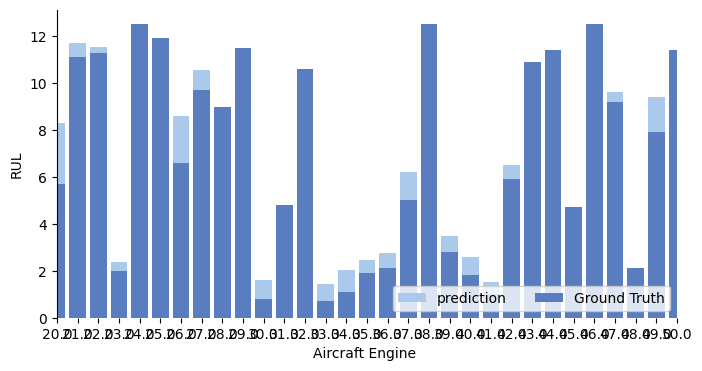

In [29]:
plot(ref, prediction,plot_pred=True,plot_ref=True)

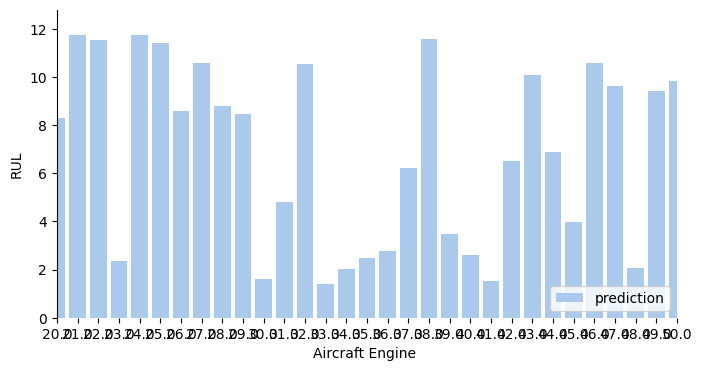

In [30]:
plot(ref, prediction,plot_pred=True,plot_ref=False)

In [31]:
def calculate_score(target, pred):
    t = torch.from_numpy(ref)
    p = torch.from_numpy(prediction)
    diff = p - t
    score = torch.sum(torch.where(diff >= 0 , torch.exp(diff/13.0) - 1 , torch.exp(-diff/10.0) - 1 )).detach().cpu().item()
    return score

In [32]:
calculate_score(ref,prediction)

384.8313902451323

In [33]:
trainer.best_score

14.08511269405284

In [ ]:
today = date.today()
trainer.save_model("/kaggle/working","best_model-{}-{}-{}".format(today,trainer.best_score,"overestim_reg"))